In [1]:
from io import StringIO

import pandas as pd
import seaborn as sns

In [2]:
csvString = """Size,Rounds,Correlation
1000,1;2;3,0.4503
1000,1,0.2096
1000,2,0.2056
1000,3,0.1642
1000,1;2,0.3695
1000,1;3,0.3578
1000,2;3,0.3354
2000,1,0.3059
3000,1,0.4243
10000,1,0.6530
100000,1,0.8596"""
csvStringIO = StringIO(csvString)
df = pd.read_csv(csvStringIO, sep=",")

In [3]:
df["num_rounds"] = df.Rounds.str.count(';') + 1

In [4]:
df["total_size"] = df["Size"] * df["num_rounds"]

In [5]:
df

,Size,Rounds,Correlation,num_rounds,total_size
0,1000,1;2;3,0.4503,3,3000
1,1000,1,0.2096,1,1000
2,1000,2,0.2056,1,1000
3,1000,3,0.1642,1,1000
4,1000,1;2,0.3695,2,2000
5,1000,1;3,0.3578,2,2000
6,1000,2;3,0.3354,2,2000
7,2000,1,0.3059,1,2000
8,3000,1,0.4243,1,3000
9,10000,1,0.6530,1,10000


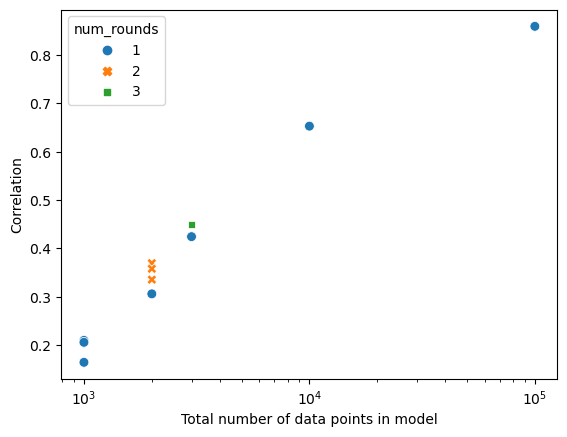

In [6]:
g = sns.scatterplot(data=df, x="total_size", y="Correlation", 
                    hue="num_rounds", style="num_rounds", s=50,
                   palette=sns.color_palette("tab10")[:3])
g.set(xscale="log", xlabel="Total number of data points in model")
g.get_figure().savefig("../output/synthetic/multiple_synthetic_results.png", dpi=300)
pass